# Cross-Country Tariff Data Normalization and Visualization

This notebook loads a parquet file, normalizes tariff-related classification columns, validates expected values, applies fuzzy matching where useful, and generates reusable visualizations with filters.


In [ ]:
# Optional dependency setup
import sys
import subprocess
import importlib.util

REQUIRED_PACKAGES = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "pyarrow": "pyarrow",
    "rapidfuzz": "rapidfuzz",
    "pycountry": "pycountry",
}

missing = [pkg for mod, pkg in REQUIRED_PACKAGES.items() if importlib.util.find_spec(mod) is None]

if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All required packages are available.")


Installing missing packages: ['rapidfuzz', 'pycountry']


In [ ]:
import ast
import json
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from rapidfuzz import process, fuzz
except Exception:
    process = None
    fuzz = None

try:
    import pycountry
except Exception:
    pycountry = None

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Input / output paths
DATA_PATH = Path("/content/drive/MyDrive/Survey Data/IMF/TARIFS_232/PROCESSED/wcb_tariff_sentiment_results_part_1.parquet")


OUTPUT_DIR = Path("/content/drive/MyDrive/Survey Data/IMF/TARIFS_232/PROCESSED/")
OUTPUT_DIR.mkdir(exist_ok=True)

CLEAN_PARQUET_PATH = OUTPUT_DIR / "wcb_tariff_normalized.parquet"
CLEAN_CSV_PATH = OUTPUT_DIR / "wcb_tariff_normalized.csv"
VALIDATION_REPORT_PATH = OUTPUT_DIR / "wcb_validation_report.csv"

DATA_PATH


PosixPath('/content/drive/MyDrive/Survey Data/IMF/TARIFS_232/PROCESSED/wcb_tariff_sentiment_results_part_1.parquet')

In [ ]:
df_raw = pd.read_parquet(DATA_PATH)
df = df_raw.copy()

print(df.shape)
display(df.head())
display(df.dtypes.to_frame("dtype").T)


(558681, 61)


,idx,Title,Author,Publication title,Publication date,Publication year,Place of publication,Location,Geographic terms,Section,Abstract,Full text,Subject,People,Company / organization,Business indexing term,Identifier / keyword,Publication subject,Source type,Document type,Language of publication,Country of publication,ProQuest document ID,Document URL,ISSN,Copyright,Publisher,Publication info,Database,Last updated,Links,Pages,Dateline,Credits,region,source_relpath,dedup_key,dedup_strategy,is_duplicate,is_duplicate_within_region,is_duplicate_across_regions,is_trade_tariff,tariff_specificity,sentiment_score,sentiment_confidence,narrative_family,narrative_subtopics,primary_sector,secondary_sector,sector_weights,imposing_countries,receiving_countries,retaliating_countries,retaliation_intensity,event_type,tariff_persistence,event_confidence,temporal_aspect,focal_country,mentioned_countries,perspective
0,0,"Discussions on rules of origin, tariffs hold up free trade pact","ANYANZWA, JAMES",The East African; Nairobi,"Dec 25, 2017",2017,Nairobi,None,NaN,None,None available.,Protracted negotiations on tariffs and rules of origin are holding back the planned implementation of a free market ...,Free trade; Negotiations; Liberalization; Tariffs,None,None,None,None,General Interest Periodicals--Kenya,Newspaper,News,English,Kenya,1979958956,https://www.proquest.com/africannews/newspapers/discussions-on-rules-origin-tariffs-hold-up-free/docview/1979958956/...,10241418,© Copyright 2017 Nation Media Group. All Rights Reserved. Provided by SyndiGate Media Inc. (Syndigate.info).,"Disco Digital Media, Inc.","ANYANZWA, JAMES.",African Newsstream,2017-12-25,http://sfx.wrlc.org/gw_test?url_ver=Z39.88-2004&amp;rft_val_fmt=info:ofi/fmt:kev:mtx:journal&amp;genre=article&amp;s...,None,None,None,AFRICA,AFRICA/ProQuestDocuments-2026-05-09 (1).txt,pqid::1979958956,proquest_id,False,False,False,True,0.95,0.0,0.80,economic,trade_remedies;rules_of_origin;tariff_offers,cross_sectoral,None,"{""cross_sectoral"": 1.0}",[],[],[],none,negotiation,None,0.90,current,None,"[""EG"", ""UG"", ""ZA"", ""ET"", ""ER"", ""AO"", ""MZ"", ""TZ""]",third_party
1,1,"Trudeau Steps Up on Trade for Canada, as America Under Trump Pulls Back","Austen, Ian; Swanson, Ana","The New York Times, International edition; New York","Dec 4, 2017",2017,New York,Beijing China; United States--US; Canada; India; Singapore; China; Quebec City Quebec Canada; Japan; Europe,NaN,World--Canada,"Partly as insurance against Nafta’s collapse and perhaps a way to show Washington it has options, Canada is chasing ...","OTTAWA — Prime Minister Justin Trudeau landed in Beijing on Sunday, with expanding trade with China at the top of hi...",North American Free Trade Agreement; Tariffs; Free trade; Trans-Pacific Partnership Agreement,"Xi Jinping; Trudeau, Justin",None,None,International Trade and World Market; Trans-Pacific Partnership; North American Free Trade Agreement; Canada; China;...,General Interest Periodicals--France,Newspaper,News,English,United States,1971826772,https://www.proquest.com/africannews/newspapers/trudeau-steps-up-on-trade-canada-as-america-under/docview/1971826772...,24747149,"Copyright International New York Times Dec 4, 2017",New York Times Company,"Austen, Ian; Swanson, Ana.",African Newsstream,2019-09-23,http://sfx.wrlc.org/gw_test?url_ver=Z39.88-2004&amp;rft_val_fmt=info:ofi/fmt:kev:mtx:journal&amp;genre=article&amp;s...,None,None,None,AFRICA,AFRICA/ProQuestDocuments-2026-05-09 (1).txt,pqid::1971826772,proquest_id,True,False,True,True,0.40,0.2,0.80,economic,trade_agreements;free_trade;protectionism,cross_sectoral,autos,"{""cross_sectoral"": 0.7, ""autos"": 0.3}",[],[],[],none,negotiation,None,0.70,current,CA,"[""CA"", ""US"", ""CN"", ""JP"", ""SG"", ""IN"", ""EU"", ""AU"", ""MX""]",domestic
2,2,Trump’s First Major Trade Fight With China Could Be Over Solar Panels,"Bradsher, Keith","The New York Times, International edition; New York","Dec 2, 2017",2017,New York,Southeast Asia; China; C

,idx,Title,Author,Publication title,Publication date,Publication year,Place of publication,Location,Geographic terms,Section,Abstract,Full text,Subject,People,Company / organization,Business indexing term,Identifier / keyword,Publication subject,Source type,Document type,Language of publication,Country of publication,ProQuest document ID,Document URL,ISSN,Copyright,Publisher,Publication info,Database,Last updated,Links,Pages,Dateline,Credits,region,source_relpath,dedup_key,dedup_strategy,is_duplicate,is_duplicate_within_region,is_duplicate_across_regions,is_trade_tariff,tariff_specificity,sentiment_score,sentiment_confidence,narrative_family,narrative_subtopics,primary_sector,secondary_sector,sector_weights,imposing_countries,receiving_countries,retaliating_countries,retaliation_intensity,event_type,tariff_persistence,event_confidence,temporal_aspect,focal_country,mentioned_countries,perspective
dtype,int64,object,object,object,object,object,object,object,float64,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,bool,bool,bool,bool,float64,float64,float64,object,object,object,object,object,object,object,object,object,object,object,float64,object,object,object,object


In [ ]:
EXPECTED_COLUMNS = [
    "is_trade_tariff", "tariff_specificity", "sentiment_score", "sentiment_confidence",
    "narrative_family", "narrative_subtopics", "primary_sector", "secondary_sector",
    "sector_weights", "imposing_countries", "receiving_countries", "retaliating_countries",
    "retaliation_intensity", "event_type", "tariff_persistence", "event_confidence",
    "temporal_aspect", "focal_country", "mentioned_countries", "perspective"
]

NARRATIVE_FAMILIES = ["economic", "political", "policy_response"]
NARRATIVE_SUBTOPICS = [
    "investment", "capex", "jobs", "supply_chain", "cpi", "inflation", "consumer_prices",
    "financial_markets", "capital_flows", "em_spillover", "bilateral_dipl",
    "national_security", "domestic_politics", "monetary_response", "fiscal_response",
    "industrial_policy", "retaliation", "exemption_request"
]
SECTORS = [
    "steel_aluminum", "autos", "tech_electronics", "textiles_apparel",
    "chemicals_pharma", "industrial_machinery", "agriculture_food",
    "energy_commodities", "consumer_goods_retail", "cross_sectoral"
]
RETALIATION_INTENSITIES = ["active", "threatened", "none"]
EVENT_TYPES = ["announcement", "implementation", "negotiation", "retaliation", "exemption", "structural", "reversal"]
TARIFF_PERSISTENCE = ["transitory", "permanent", "anticipated"]
TEMPORAL_ASPECTS = ["future", "current", "past"]
PERSPECTIVES = ["domestic", "bilateral", "third_party"]

COUNTRY_ALLOWLIST = {
    "US", "CA", "GB", "AU", "DE", "FR", "IT", "JP", "CN", "IN", "KR", "SG", "ES", "NL", "BR", "MX", "EU"
}

ALIASES = {
    "usa": "US", "u.s.": "US", "u.s.a.": "US", "united states": "US", "america": "US",
    "uk": "GB", "u.k.": "GB", "britain": "GB", "united kingdom": "GB",
    "south korea": "KR", "korea": "KR",
    "european union": "EU", "e.u.": "EU", "europe": "EU",
    "china": "CN", "japan": "JP", "canada": "CA", "australia": "AU",
    "germany": "DE", "france": "FR", "italy": "IT", "india": "IN",
    "singapore": "SG", "spain": "ES", "netherlands": "NL", "brazil": "BR", "mexico": "MX",
}

for col in EXPECTED_COLUMNS:
    if col not in df.columns:
        df[col] = pd.NA


In [ ]:
def is_missing(value):
    if value is None:
        return True
    if isinstance(value, float) and np.isnan(value):
        return True
    if pd.isna(value) is True:
        return True
    if isinstance(value, str) and value.strip().lower() in {"", "nan", "none", "null", "na", "n/a"}:
        return True
    return False


def clean_token(value):
    if is_missing(value):
        return None
    value = str(value).strip()
    value = value.replace("-", "_").replace(" ", "_")
    value = re.sub(r"[^A-Za-z0-9_./]", "", value)
    value = re.sub(r"_+", "_", value)
    return value.lower().strip("_")


def fuzzy_choice(value, choices, threshold=78, aliases=None):
    if is_missing(value):
        return None
    aliases = aliases or {}
    raw = str(value).strip()
    norm = clean_token(raw)
    if norm in aliases:
        return aliases[norm]
    if raw in choices:
        return raw
    if norm in choices:
        return norm
    normalized_choices = {clean_token(c): c for c in choices}
    if norm in normalized_choices:
        return normalized_choices[norm]
    if process is not None:
        match = process.extractOne(norm, list(normalized_choices.keys()), scorer=fuzz.WRatio)
        if match and match[1] >= threshold:
            return normalized_choices[match[0]]
    return None


def parse_bool(value):
    if is_missing(value):
        return pd.NA
    if isinstance(value, bool):
        return value
    if isinstance(value, (int, np.integer, float, np.floating)):
        if pd.isna(value):
            return pd.NA
        return bool(int(value))
    text = str(value).strip().lower()
    if text in {"true", "t", "yes", "y", "1"}:
        return True
    if text in {"false", "f", "no", "n", "0"}:
        return False
    return pd.NA


def parse_float(value, min_value=None, max_value=None):
    if is_missing(value):
        return np.nan
    try:
        number = float(str(value).strip().replace(",", "."))
    except Exception:
        return np.nan
    if min_value is not None:
        number = max(min_value, number)
    if max_value is not None:
        number = min(max_value, number)
    return number


def safe_literal(value):
    if is_missing(value):
        return None
    if isinstance(value, (list, dict, tuple, set)):
        return value
    text = str(value).strip()
    try:
        return json.loads(text)
    except Exception:
        pass
    try:
        return ast.literal_eval(text)
    except Exception:
        return text


def parse_semicolon_list(value):
    if is_missing(value):
        return []
    parsed = safe_literal(value)
    if isinstance(parsed, str):
        parts = re.split(r"[;|,]", parsed)
    elif isinstance(parsed, (list, tuple, set)):
        parts = list(parsed)
    else:
        parts = [parsed]
    return [str(p).strip() for p in parts if not is_missing(p)]


def normalize_subtopics(value):
    topics = []
    for item in parse_semicolon_list(value):
        matched = fuzzy_choice(item, NARRATIVE_SUBTOPICS, threshold=80)
        if matched and matched not in topics:
            topics.append(matched)
    return ";".join(topics) if topics else pd.NA


def normalize_country_code(value):
    if is_missing(value):
        return None
    raw = str(value).strip()
    norm = raw.lower().strip()
    norm_clean = clean_token(raw)
    if norm_clean in ALIASES:
        return ALIASES[norm_clean]
    upper = raw.upper().strip()
    if upper == "UK":
        return "GB"
    if upper in COUNTRY_ALLOWLIST:
        return upper
    if re.fullmatch(r"[A-Z]{2}", upper):
        return upper
    if pycountry is not None:
        try:
            return pycountry.countries.lookup(raw).alpha_2
        except Exception:
            pass
    return None


def normalize_country_list(value):
    countries = []
    for item in parse_semicolon_list(value):
        code = normalize_country_code(item)
        if code and code not in countries:
            countries.append(code)
    return countries


def normalize_sector_weights(value):
    parsed = safe_literal(value)
    if is_missing(parsed):
        return {}
    if isinstance(parsed, str):
        items = {}
        for part in re.split(r"[;|,]", parsed):
            if ":" in part:
                k, v = part.split(":", 1)
                items[k.strip()] = v.strip()
        parsed = items
    if not isinstance(parsed, dict):
        return {}

    cleaned = {}
    for key, weight in parsed.items():
        sector = fuzzy_choice(key, SECTORS, threshold=78)
        if sector is None:
            continue
        try:
            w = float(weight)
        except Exception:
            continue
        if np.isfinite(w) and w > 0:
            cleaned[sector] = cleaned.get(sector, 0.0) + w

    total = sum(cleaned.values())
    if total <= 0:
        return {}
    return {k: round(v / total, 6) for k, v in sorted(cleaned.items())}


def normalize_categorical_series(series, choices, threshold=78):
    return series.apply(lambda x: fuzzy_choice(x, choices, threshold=threshold))


def normalize_dataframe(input_df):
    out = input_df.copy()

    out["is_trade_tariff"] = out["is_trade_tariff"].apply(parse_bool).astype("boolean")
    out["tariff_specificity"] = out["tariff_specificity"].apply(lambda x: parse_float(x, 0.0, 1.0))
    out["sentiment_score"] = out["sentiment_score"].apply(lambda x: parse_float(x, -1.0, 1.0))
    out["sentiment_confidence"] = out["sentiment_confidence"].apply(lambda x: parse_float(x, 0.0, 1.0))
    out["event_confidence"] = out["event_confidence"].apply(lambda x: parse_float(x, 0.0, 1.0))

    out["narrative_family"] = normalize_categorical_series(out["narrative_family"], NARRATIVE_FAMILIES, threshold=78)
    out["narrative_subtopics"] = out["narrative_subtopics"].apply(normalize_subtopics)
    out["primary_sector"] = normalize_categorical_series(out["primary_sector"], SECTORS, threshold=78)
    out["secondary_sector"] = normalize_categorical_series(out["secondary_sector"], SECTORS, threshold=78)
    out["retaliation_intensity"] = normalize_categorical_series(out["retaliation_intensity"], RETALIATION_INTENSITIES, threshold=75)
    out["event_type"] = normalize_categorical_series(out["event_type"], EVENT_TYPES, threshold=75)
    out["tariff_persistence"] = normalize_categorical_series(out["tariff_persistence"], TARIFF_PERSISTENCE, threshold=75)
    out["temporal_aspect"] = normalize_categorical_series(out["temporal_aspect"], TEMPORAL_ASPECTS, threshold=75)
    out["perspective"] = normalize_categorical_series(out["perspective"], PERSPECTIVES, threshold=75)

    out["sector_weights"] = out["sector_weights"].apply(normalize_sector_weights)
    out["imposing_countries"] = out["imposing_countries"].apply(normalize_country_list)
    out["receiving_countries"] = out["receiving_countries"].apply(normalize_country_list)
    out["retaliating_countries"] = out["retaliating_countries"].apply(normalize_country_list)
    out["mentioned_countries"] = out["mentioned_countries"].apply(normalize_country_list)
    out["focal_country"] = out["focal_country"].apply(normalize_country_code)

    if "Publication date" in out.columns:
        out["Publication date"] = pd.to_datetime(out["Publication date"], errors="coerce")
    if "Publication year" in out.columns:
        out["Publication year"] = pd.to_numeric(out["Publication year"], errors="coerce").astype("Int64")

    return out


df_clean = normalize_dataframe(df)
display(df_clean[EXPECTED_COLUMNS].head())


,is_trade_tariff,tariff_specificity,sentiment_score,sentiment_confidence,narrative_family,narrative_subtopics,primary_sector,secondary_sector,sector_weights,imposing_countries,receiving_countries,retaliating_countries,retaliation_intensity,event_type,tariff_persistence,event_confidence,temporal_aspect,focal_country,mentioned_countries,perspective
0,True,0.95,0.0,0.80,economic,<NA>,cross_sectoral,None,{'cross_sectoral': 1.0},[],[],[],None,negotiation,None,0.90,current,None,"[EG, UG, ZA, ET, ER, AO, MZ, TZ]",third_party
1,True,0.40,0.2,0.80,economic,<NA>,cross_sectoral,autos,"{'autos': 0.3, 'cross_sectoral': 0.7}",[],[],[],None,negotiation,None,0.70,current,CA,"[CA, US, CN, JP, SG, IN, EU, AU, MX]",domestic
2,True,0.95,-1.0,0.90,economic,investment;jobs;supply_chain;retaliation,tech_electronics,energy_commodities,"{'energy_commodities': 0.3, 'tech_electronics': 0.7}",[US],[CN],[CN],threatened,announcement,anticipated,0.90,future,US,"[US, CN]",domestic
3,False,0.00,0.0,0.95,None,<NA>,None,None,{},[],[],[],None,None,None,0.00,current,KE,[KE],domestic
4,True,0.90,0.0,0.80,policy_response,<NA>,agriculture_food,industrial_machinery,"{'agriculture_food': 0.6, 'industrial_machinery': 0.4}",[NG],[],[],None,structural,permanent,0.85,current,NG,[NG],domestic


In [ ]:
df_clean[EXPECTED_COLUMNS].sample(5,random_state=42)

,is_trade_tariff,tariff_specificity,sentiment_score,sentiment_confidence,narrative_family,narrative_subtopics,primary_sector,secondary_sector,sector_weights,imposing_countries,receiving_countries,retaliating_countries,retaliation_intensity,event_type,tariff_persistence,event_confidence,temporal_aspect,focal_country,mentioned_countries,perspective
169463,True,0.7,-1.0,0.90,economic,<NA>,cross_sectoral,None,{'cross_sectoral': 1.0},[EU],[GB],[],None,negotiation,permanent,0.9,future,GB,"[GB, EU]",domestic
359189,False,0.0,0.0,0.95,None,<NA>,None,None,{},[],[],[],None,None,None,0.0,past,BR,"[BR, US]",domestic
533498,True,0.6,-1.0,0.80,economic,investment;supply_chain;financial_markets,tech_electronics,None,{'tech_electronics': 1.0},[US],"[CN, TW]",[],None,announcement,permanent,0.7,current,US,"[US, CN, TW]",domestic
15613,False,0.0,0.0,0.95,None,<NA>,None,None,{},[],[],[],None,None,None,0.0,current,ZA,[ZA],domestic
458171,False,0.0,0.0,0.95,None,<NA>,None,None,{},[],[],[],None,None,None,0.0,current,PE,"[PE, GB]",third_party


In [ ]:
df[EXPECTED_COLUMNS].sample(5,random_state=42)

,is_trade_tariff,tariff_specificity,sentiment_score,sentiment_confidence,narrative_family,narrative_subtopics,primary_sector,secondary_sector,sector_weights,imposing_countries,receiving_countries,retaliating_countries,retaliation_intensity,event_type,tariff_persistence,event_confidence,temporal_aspect,focal_country,mentioned_countries,perspective
169463,True,0.7,-1.0,0.90,economic,trade_negotiation;brexit;tariff_free_access,cross_sectoral,None,"{""cross_sectoral"": 1.0}","[""EU""]","[""GB""]",[],none,negotiation,permanent,0.9,future,GB,"[""GB"", ""EU""]",domestic
359189,False,0.0,0.0,0.95,None,None,None,None,{},[],[],[],none,None,None,0.0,past,BR,"[""BR"", ""US""]",domestic
533498,True,0.6,-1.0,0.80,economic,investment;supply_chain;financial_markets,tech_electronics,None,"{""tech_electronics"": 1.0}","[""US""]","[""CN"", ""TW""]",[],none,announcement,permanent,0.7,current,US,"[""US"", ""CN"", ""TW""]",domestic
15613,False,0.0,0.0,0.95,None,None,None,None,{},[],[],[],none,None,None,0.0,current,ZA,"[""ZA""]",domestic
458171,False,0.0,0.0,0.95,None,None,None,None,{},[],[],[],none,None,None,0.0,current,PE,"[""PE"", ""GB""]",third_party


In [ ]:
def validation_summary(data):
    checks = []

    def add_check(column, invalid_mask, expected):
        checks.append({
            "column": column,
            "expected": expected,
            "invalid_count": int(invalid_mask.sum()),
            "invalid_share": float(invalid_mask.mean()) if len(invalid_mask) else 0.0,
            "missing_count": int(data[column].isna().sum()) if column in data else None,
        })

    add_check("is_trade_tariff", data["is_trade_tariff"].isna(), "boolean")
    add_check("tariff_specificity", data["tariff_specificity"].isna() | ~data["tariff_specificity"].between(0, 1), "0.0 to 1.0")
    add_check("sentiment_score", data["sentiment_score"].isna() | ~data["sentiment_score"].between(-1, 1), "-1.0 to 1.0")
    add_check("sentiment_confidence", data["sentiment_confidence"].isna() | ~data["sentiment_confidence"].between(0, 1), "0.0 to 1.0")
    add_check("event_confidence", data["event_confidence"].isna() | ~data["event_confidence"].between(0, 1), "0.0 to 1.0")

    categorical_specs = {
        "narrative_family": NARRATIVE_FAMILIES,
        "primary_sector": SECTORS,
        "secondary_sector": SECTORS,
        "retaliation_intensity": RETALIATION_INTENSITIES,
        "event_type": EVENT_TYPES,
        "tariff_persistence": TARIFF_PERSISTENCE,
        "temporal_aspect": TEMPORAL_ASPECTS,
        "perspective": PERSPECTIVES,
    }
    for col, choices in categorical_specs.items():
        add_check(col, data[col].notna() & ~data[col].isin(choices), ", ".join(choices))

    country_cols = ["imposing_countries", "receiving_countries", "retaliating_countries", "mentioned_countries"]
    for col in country_cols:
        invalid = data[col].apply(lambda x: not isinstance(x, list) or any(normalize_country_code(v) is None for v in x))
        add_check(col, invalid, "list of ISO 2-letter codes")

    invalid_focal = data["focal_country"].notna() & data["focal_country"].apply(lambda x: normalize_country_code(x) is None)
    add_check("focal_country", invalid_focal, "ISO 2-letter code or null")

    invalid_weights = data["sector_weights"].apply(lambda x: not isinstance(x, dict) or (len(x) > 0 and abs(sum(x.values()) - 1.0) > 1e-3))
    add_check("sector_weights", invalid_weights, "dict with normalized sector weights")

    return pd.DataFrame(checks).sort_values(["invalid_count", "missing_count"], ascending=False)


validation_report = validation_summary(df_clean)
display(validation_report)
validation_report.to_csv(VALIDATION_REPORT_PATH, index=False)


,column,expected,invalid_count,invalid_share,missing_count
16,mentioned_countries,list of ISO 2-letter codes,7,0.000013,0
7,secondary_sector,"steel_aluminum, autos, tech_electronics, textiles_apparel, chemicals_pharma, industrial_machinery, agriculture_food,...",0,0.000000,433935
8,retaliation_intensity,"active, threatened, none",0,0.000000,423454
10,tariff_persistence,"transitory, permanent, anticipated",0,0.000000,241002
9,event_type,"announcement, implementation, negotiation, retaliation, exemption, structural, reversal",0,0.000000,169507
6,primary_sector,"steel_aluminum, autos, tech_electronics, textiles_apparel, chemicals_pharma, industrial_machinery, agriculture_food,...",0,0.000000,163913
5,narrative_family,"economic, political, policy_response",0,0.000000,160817
11,temporal_aspect,"future, current, past",0,0.000000,29876
17,focal_country,ISO 2-letter code or null,0,0.000000,27619
0,is_trade_tariff,boolean,0,0.000000,0


In [ ]:
def filter_data(
    data,
    start_date=None,
    end_date=None,
    years=None,
    region=None,
    source_type=None,
    is_trade_tariff=None,
    event_type=None,
    narrative_family=None,
    primary_sector=None,
    focal_country=None,
    mentioned_country=None,
    min_event_confidence=None,
    min_sentiment_confidence=None,
):
    out = data.copy()

    if start_date is not None and "Publication date" in out:
        out = out[out["Publication date"] >= pd.to_datetime(start_date)]
    if end_date is not None and "Publication date" in out:
        out = out[out["Publication date"] <= pd.to_datetime(end_date)]
    if years is not None and "Publication year" in out:
        years = [years] if isinstance(years, int) else list(years)
        out = out[out["Publication year"].isin(years)]
    if region is not None and "region" in out:
        values = [region] if isinstance(region, str) else list(region)
        out = out[out["region"].isin(values)]
    if source_type is not None and "Source type" in out:
        values = [source_type] if isinstance(source_type, str) else list(source_type)
        out = out[out["Source type"].isin(values)]
    if is_trade_tariff is not None:
        out = out[out["is_trade_tariff"] == bool(is_trade_tariff)]
    if event_type is not None:
        values = [event_type] if isinstance(event_type, str) else list(event_type)
        out = out[out["event_type"].isin(values)]
    if narrative_family is not None:
        values = [narrative_family] if isinstance(narrative_family, str) else list(narrative_family)
        out = out[out["narrative_family"].isin(values)]
    if primary_sector is not None:
        values = [primary_sector] if isinstance(primary_sector, str) else list(primary_sector)
        out = out[out["primary_sector"].isin(values)]
    if focal_country is not None:
        values = [normalize_country_code(focal_country)] if isinstance(focal_country, str) else [normalize_country_code(v) for v in focal_country]
        out = out[out["focal_country"].isin(values)]
    if mentioned_country is not None:
        values = [normalize_country_code(mentioned_country)] if isinstance(mentioned_country, str) else [normalize_country_code(v) for v in mentioned_country]
        out = out[out["mentioned_countries"].apply(lambda xs: any(v in xs for v in values if v))]
    if min_event_confidence is not None:
        out = out[out["event_confidence"] >= min_event_confidence]
    if min_sentiment_confidence is not None:
        out = out[out["sentiment_confidence"] >= min_sentiment_confidence]

    return out


In [ ]:
def plot_bar_counts(data, column, top_n=20, title=None, horizontal=True):
    counts = data[column].dropna().astype(str).value_counts().head(top_n)
    if counts.empty:
        print(f"No data available for {column}.")
        return
    plt.figure(figsize=(10, max(4, 0.35 * len(counts))) if horizontal else (10, 5))
    if horizontal:
        counts.sort_values().plot(kind="barh")
        plt.xlabel("Count")
        plt.ylabel(column)
    else:
        counts.plot(kind="bar")
        plt.xlabel(column)
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
    plt.title(title or f"{column} distribution")
    plt.tight_layout()
    plt.show()


def plot_numeric_distribution(data, column, bins=30, title=None):
    values = pd.to_numeric(data[column], errors="coerce").dropna()
    if values.empty:
        print(f"No numeric data available for {column}.")
        return
    plt.figure(figsize=(9, 5))
    plt.hist(values, bins=bins)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title(title or f"{column} distribution")
    plt.tight_layout()
    plt.show()


def plot_multilabel_counts(data, column, top_n=25, separator=";", title=None):
    counter = Counter()
    for value in data[column].dropna():
        if isinstance(value, list):
            labels = value
        elif isinstance(value, str):
            labels = [x.strip() for x in value.split(separator) if x.strip()]
        else:
            labels = []
        counter.update(labels)
    counts = pd.Series(counter).sort_values(ascending=False).head(top_n)
    if counts.empty:
        print(f"No multilabel data available for {column}.")
        return
    plt.figure(figsize=(10, max(4, 0.35 * len(counts))))
    counts.sort_values().plot(kind="barh")
    plt.xlabel("Count")
    plt.ylabel(column)
    plt.title(title or f"{column} counts")
    plt.tight_layout()
    plt.show()


def plot_country_role_counts(data, columns=None, top_n=25):
    columns = columns or ["imposing_countries", "receiving_countries", "retaliating_countries", "mentioned_countries"]
    rows = []
    for col in columns:
        for countries in data[col].dropna():
            if isinstance(countries, list):
                for country in countries:
                    rows.append({"role": col.replace("_countries", ""), "country": country})
    role_df = pd.DataFrame(rows)
    if role_df.empty:
        print("No country-role data available.")
        return role_df
    counts = role_df.value_counts(["country", "role"]).reset_index(name="count")
    top_countries = counts.groupby("country")["count"].sum().sort_values(ascending=False).head(top_n).index
    pivot = counts[counts["country"].isin(top_countries)].pivot(index="country", columns="role", values="count").fillna(0)
    pivot = pivot.loc[pivot.sum(axis=1).sort_values().index]
    plt.figure(figsize=(10, max(4, 0.35 * len(pivot))))
    left = np.zeros(len(pivot))
    for role in pivot.columns:
        plt.barh(pivot.index, pivot[role], left=left, label=role)
        left += pivot[role].values
    plt.xlabel("Count")
    plt.ylabel("Country")
    plt.title("Country mentions by role")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return counts


def plot_time_series(data, date_col="Publication date", group_col=None, freq="M", title=None):
    if date_col not in data.columns:
        print(f"{date_col} not found.")
        return
    temp = data.dropna(subset=[date_col]).copy()
    if temp.empty:
        print("No date data available.")
        return
    temp["_period"] = temp[date_col].dt.to_period(freq).dt.to_timestamp()
    plt.figure(figsize=(11, 5))
    if group_col is None:
        temp.groupby("_period").size().plot()
    else:
        pivot = temp.groupby(["_period", group_col]).size().unstack(fill_value=0)
        for col in pivot.columns:
            plt.plot(pivot.index, pivot[col], label=str(col))
        plt.legend()
    plt.xlabel("Date")
    plt.ylabel("Count")
    plt.title(title or ("Article count over time" if group_col is None else f"Article count over time by {group_col}"))
    plt.tight_layout()
    plt.show()


def plot_crosstab_heatmap(data, row_col, col_col, normalize=False, title=None):
    table = pd.crosstab(data[row_col], data[col_col], normalize="index" if normalize else False)
    if table.empty:
        print("No crosstab data available.")
        return table
    plt.figure(figsize=(max(7, 0.8 * len(table.columns)), max(5, 0.45 * len(table.index))))
    plt.imshow(table.values, aspect="auto")
    plt.xticks(range(len(table.columns)), table.columns, rotation=45, ha="right")
    plt.yticks(range(len(table.index)), table.index)
    plt.colorbar(label="Share" if normalize else "Count")
    plt.title(title or f"{row_col} × {col_col}")
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            value = table.iloc[i, j]
            text = f"{value:.2f}" if normalize else f"{int(value)}"
            plt.text(j, i, text, ha="center", va="center")
    plt.tight_layout()
    plt.show()
    return table


def plot_sector_weights(data, top_n=20):
    rows = []
    for weights in data["sector_weights"].dropna():
        if isinstance(weights, dict):
            for sector, weight in weights.items():
                rows.append({"sector": sector, "weight": weight})
    weights_df = pd.DataFrame(rows)
    if weights_df.empty:
        print("No sector weight data available.")
        return weights_df
    avg_weights = weights_df.groupby("sector")["weight"].mean().sort_values(ascending=False).head(top_n)
    plt.figure(figsize=(10, max(4, 0.35 * len(avg_weights))))
    avg_weights.sort_values().plot(kind="barh")
    plt.xlabel("Average normalized weight")
    plt.ylabel("Sector")
    plt.title("Average sector weights")
    plt.tight_layout()
    plt.show()
    return avg_weights


In [ ]:
analysis_df = filter_data(
    df_clean,
    is_trade_tariff=True,
    min_event_confidence=None,
    min_sentiment_confidence=None,
)

print(analysis_df.shape)


(392730, 61)


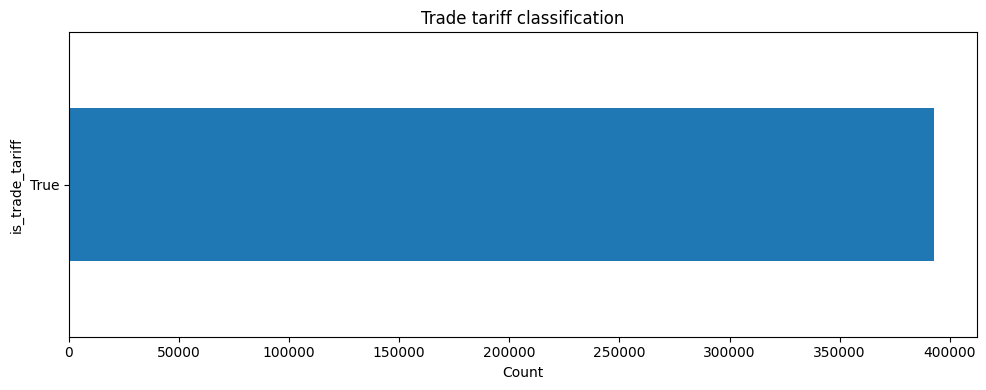

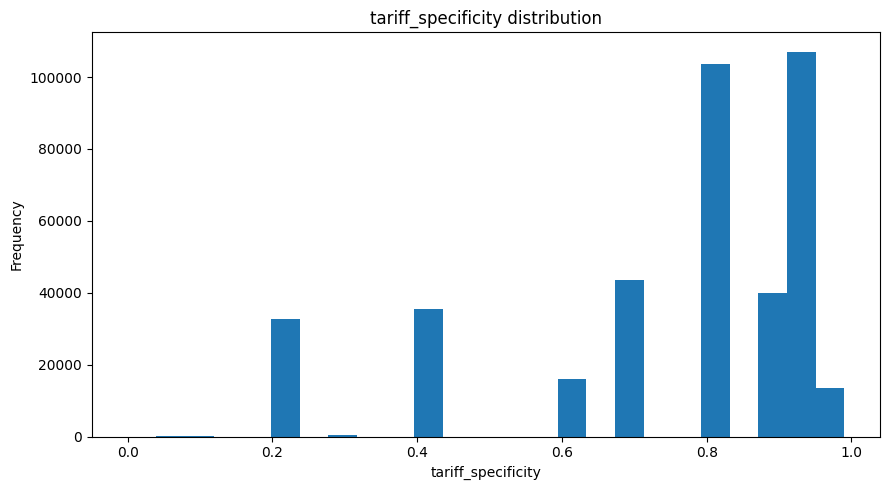

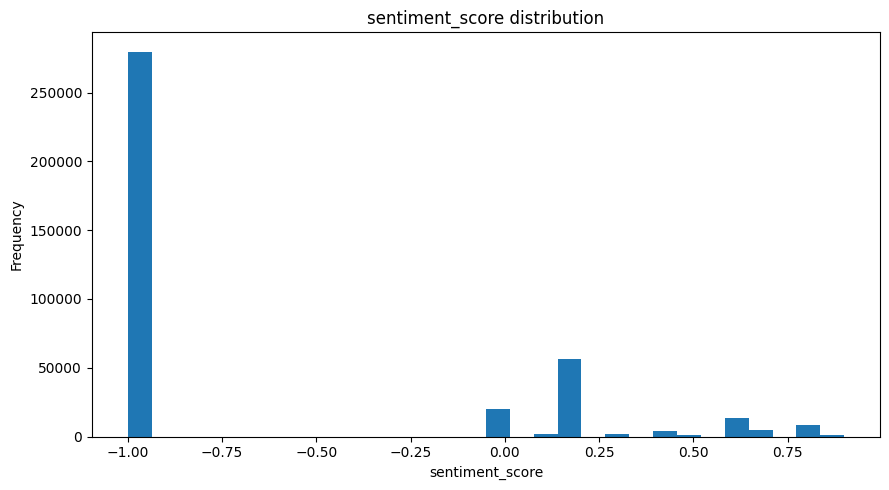

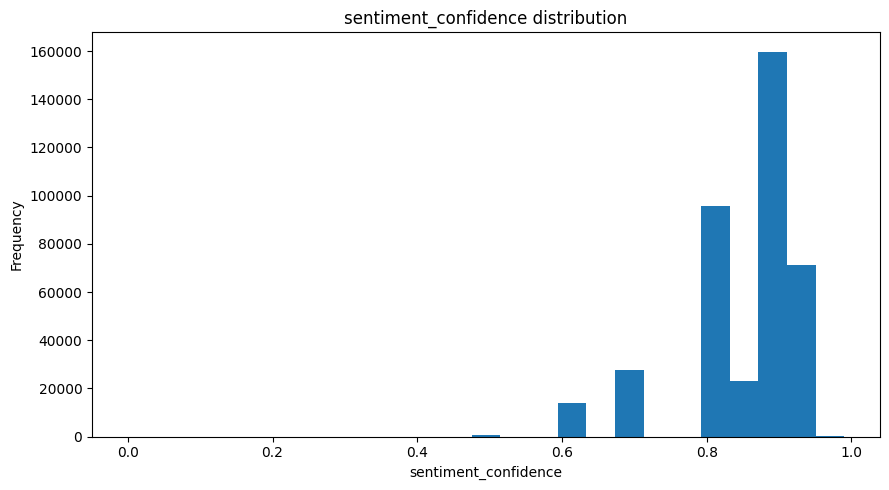

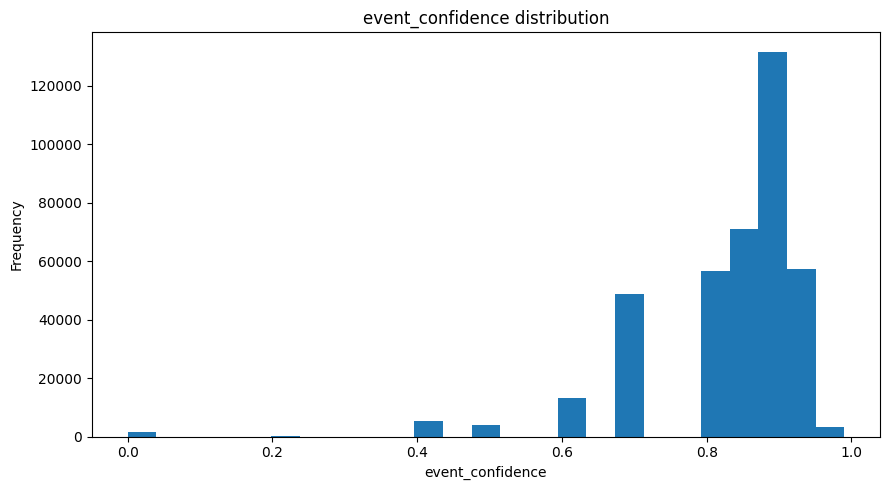

In [ ]:
plot_bar_counts(analysis_df, "is_trade_tariff", title="Trade tariff classification")
plot_numeric_distribution(analysis_df, "tariff_specificity", bins=25)
plot_numeric_distribution(analysis_df, "sentiment_score", bins=30)
plot_numeric_distribution(analysis_df, "sentiment_confidence", bins=25)
plot_numeric_distribution(analysis_df, "event_confidence", bins=25)


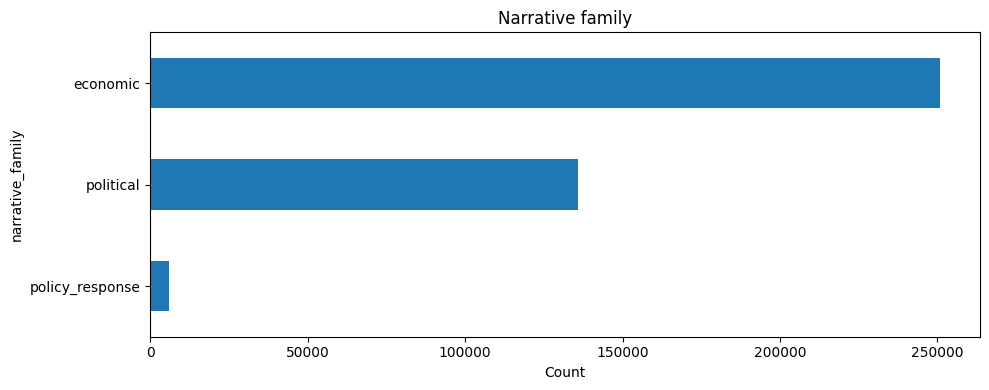

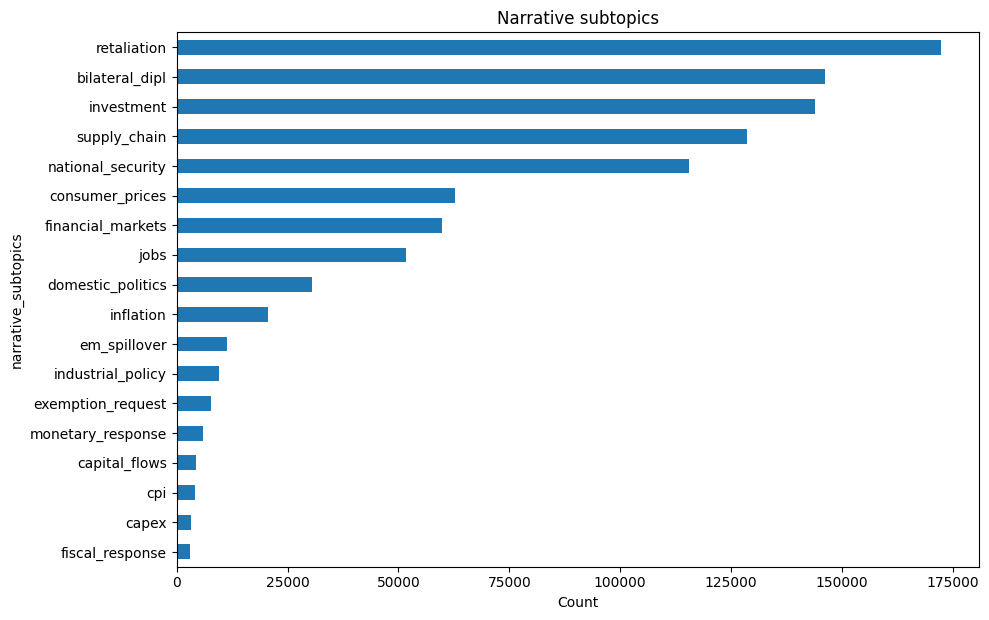

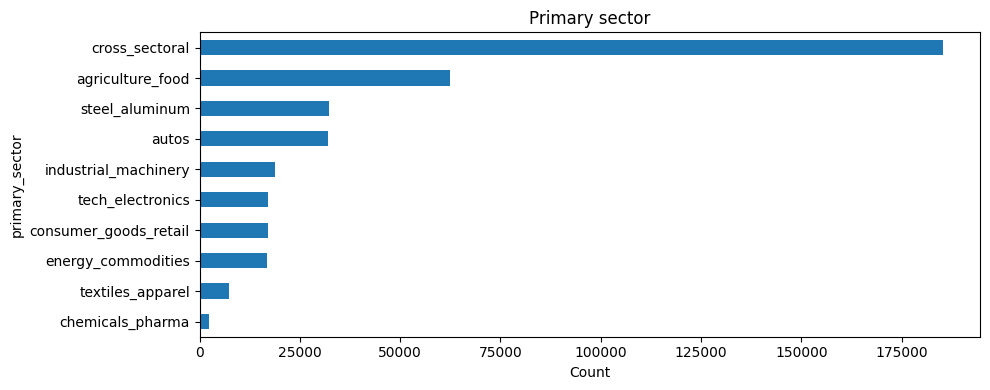

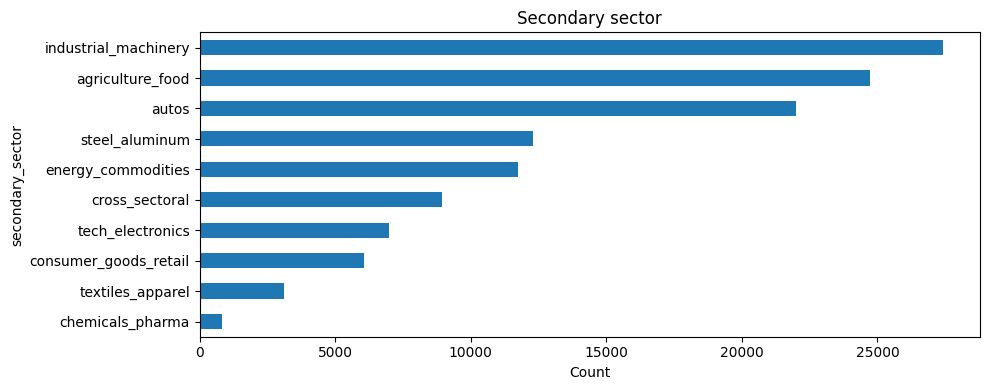

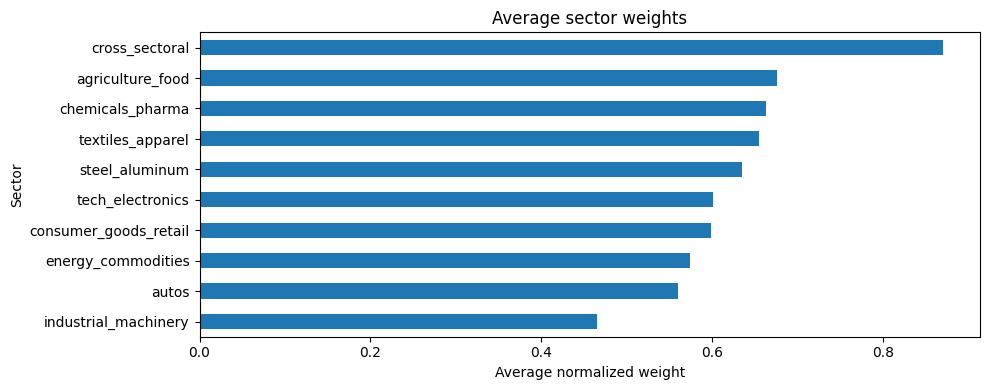

,weight
sector,
cross_sectoral,0.870390
agriculture_food,0.675911
chemicals_pharma,0.663794
textiles_apparel,0.655074
steel_aluminum,0.635158
tech_electronics,0.601738
consumer_goods_retail,0.598564
energy_commodities,0.574607
autos,0.560285


In [ ]:
plot_bar_counts(analysis_df, "narrative_family", title="Narrative family")
plot_multilabel_counts(analysis_df, "narrative_subtopics", title="Narrative subtopics")
plot_bar_counts(analysis_df, "primary_sector", title="Primary sector")
plot_bar_counts(analysis_df, "secondary_sector", title="Secondary sector")
plot_sector_weights(analysis_df)


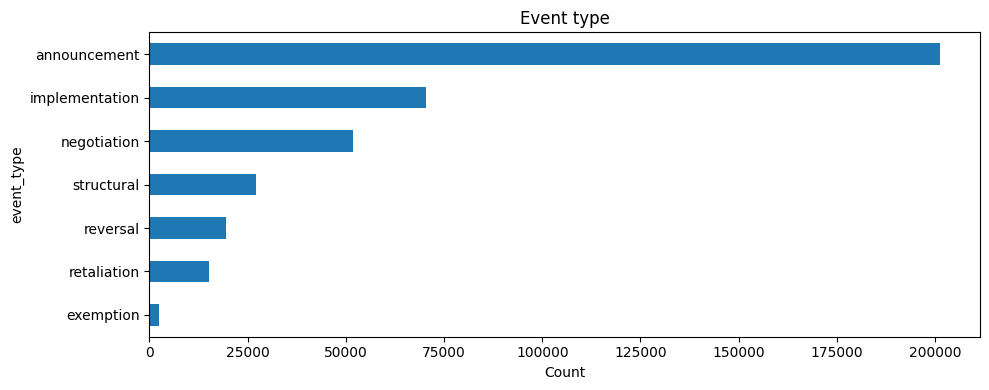

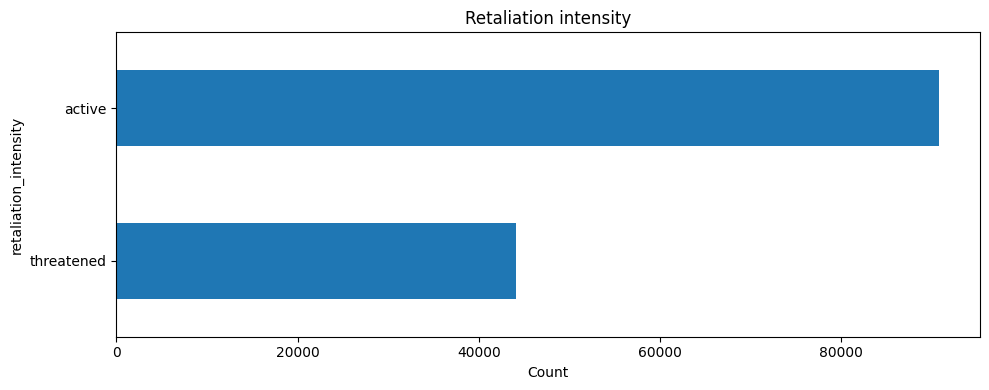

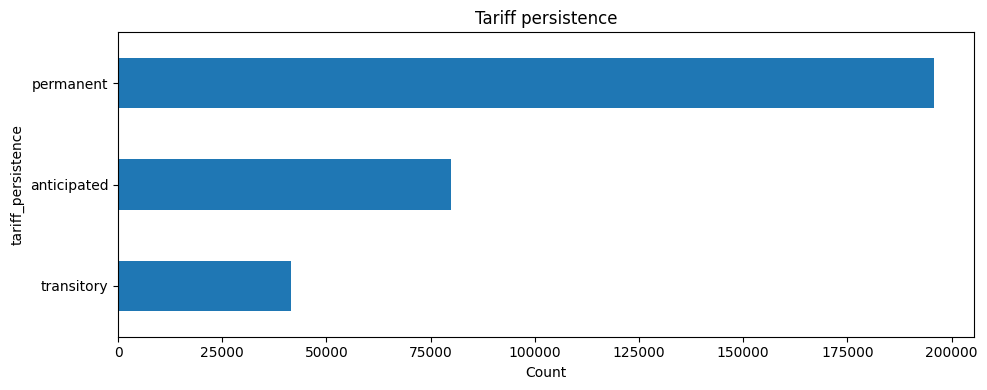

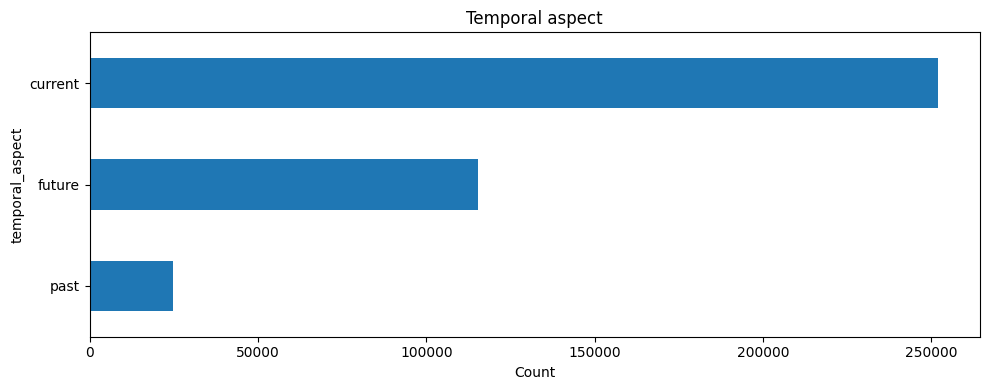

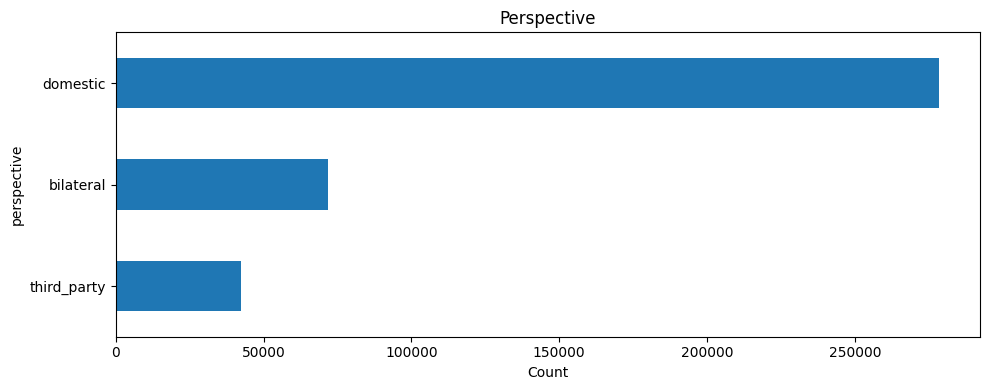

In [ ]:
plot_bar_counts(analysis_df, "event_type", title="Event type")
plot_bar_counts(analysis_df, "retaliation_intensity", title="Retaliation intensity")
plot_bar_counts(analysis_df, "tariff_persistence", title="Tariff persistence")
plot_bar_counts(analysis_df, "temporal_aspect", title="Temporal aspect")
plot_bar_counts(analysis_df, "perspective", title="Perspective")


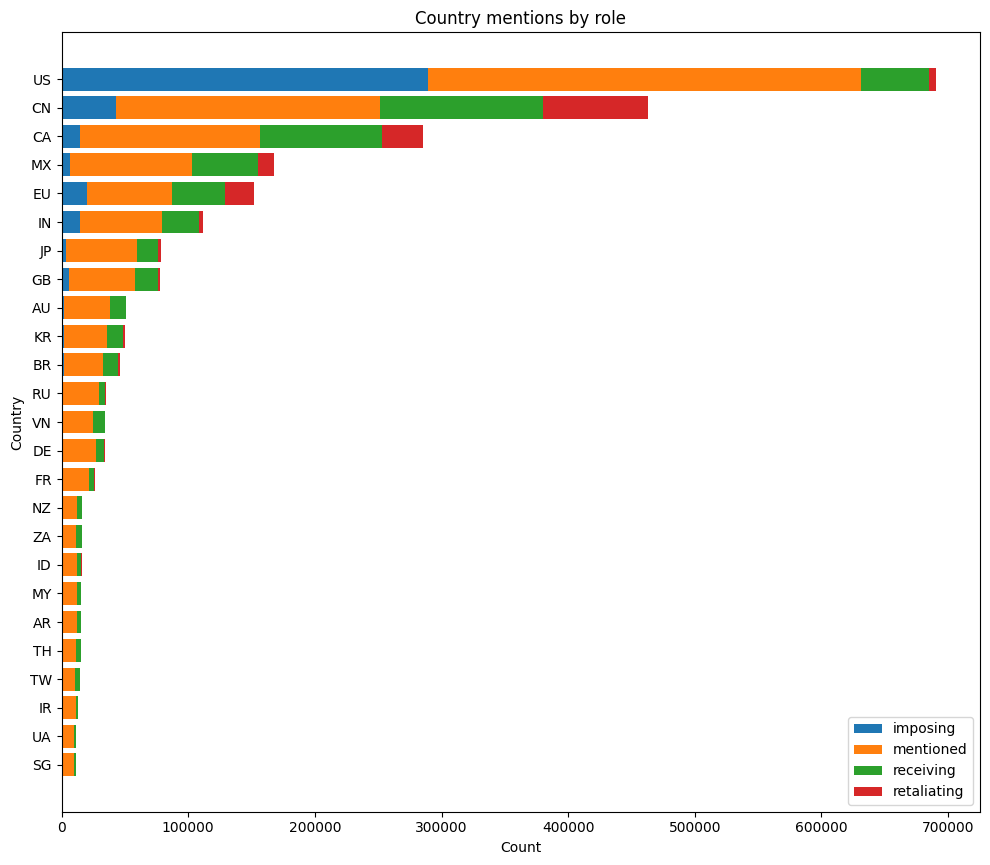

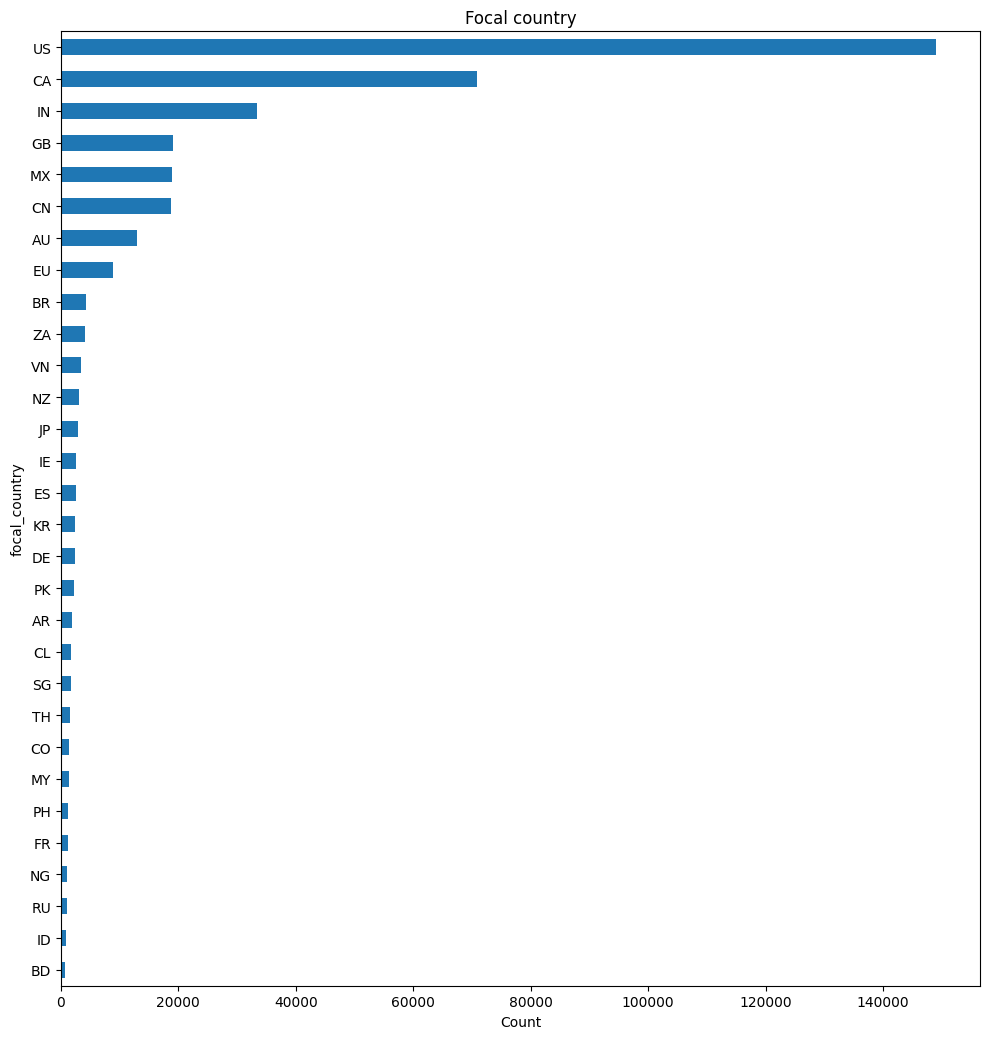

In [ ]:
plot_country_role_counts(analysis_df)
plot_bar_counts(analysis_df, "focal_country", title="Focal country", top_n=30)


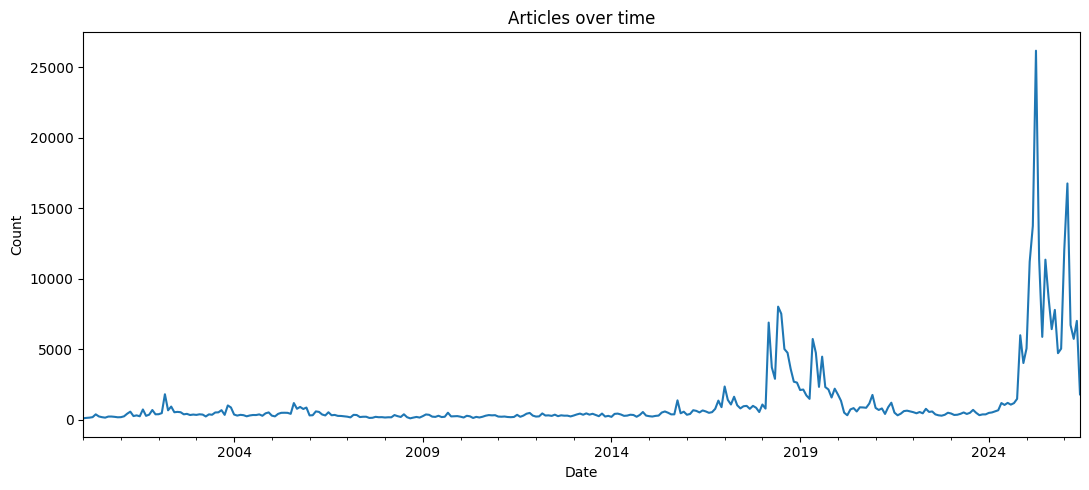

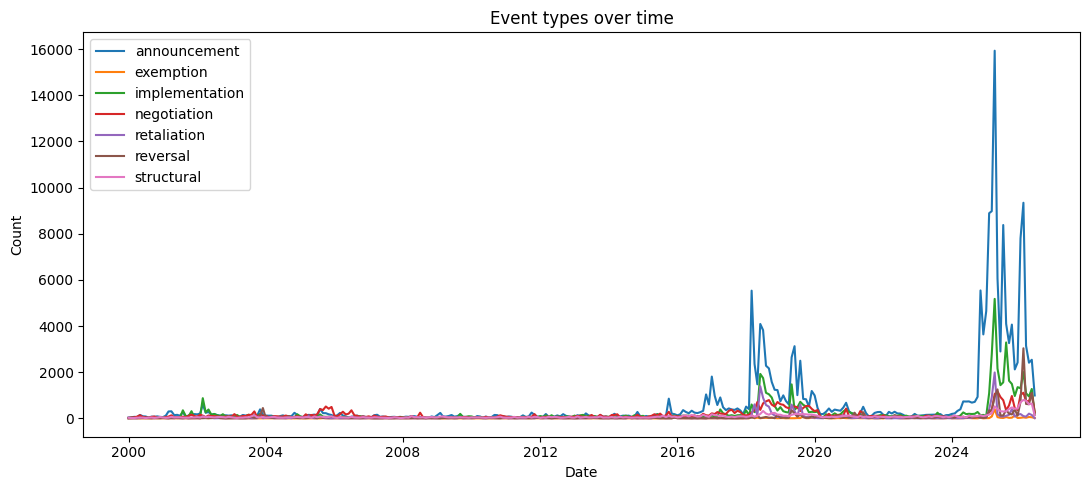

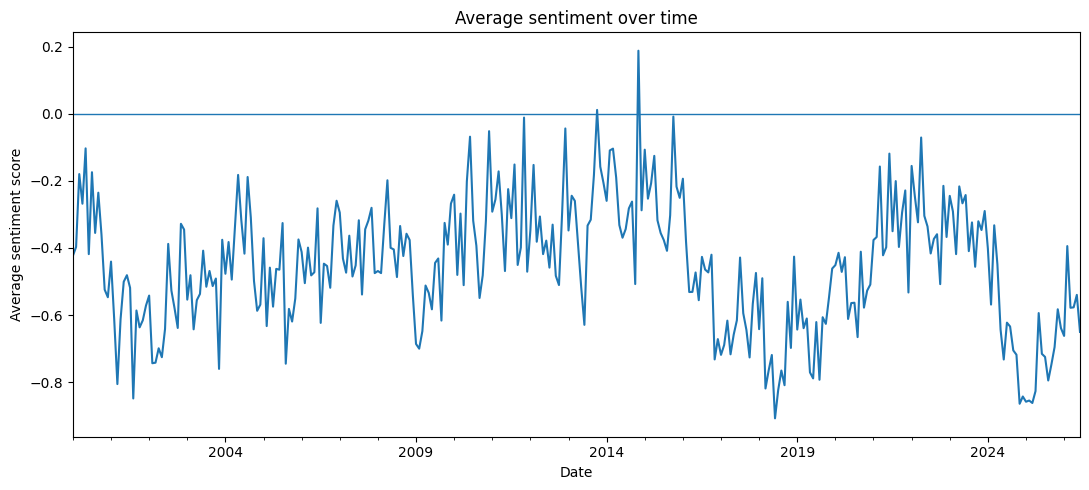

In [ ]:
plot_time_series(analysis_df, group_col=None, freq="M", title="Articles over time")
plot_time_series(analysis_df, group_col="event_type", freq="M", title="Event types over time")

if "Publication date" in analysis_df.columns:
    sentiment_monthly = (
        analysis_df.dropna(subset=["Publication date", "sentiment_score"])
        .assign(period=lambda x: x["Publication date"].dt.to_period("M").dt.to_timestamp())
        .groupby("period")["sentiment_score"]
        .mean()
    )
    if not sentiment_monthly.empty:
        plt.figure(figsize=(11, 5))
        sentiment_monthly.plot()
        plt.axhline(0, linewidth=1)
        plt.xlabel("Date")
        plt.ylabel("Average sentiment score")
        plt.title("Average sentiment over time")
        plt.tight_layout()
        plt.show()


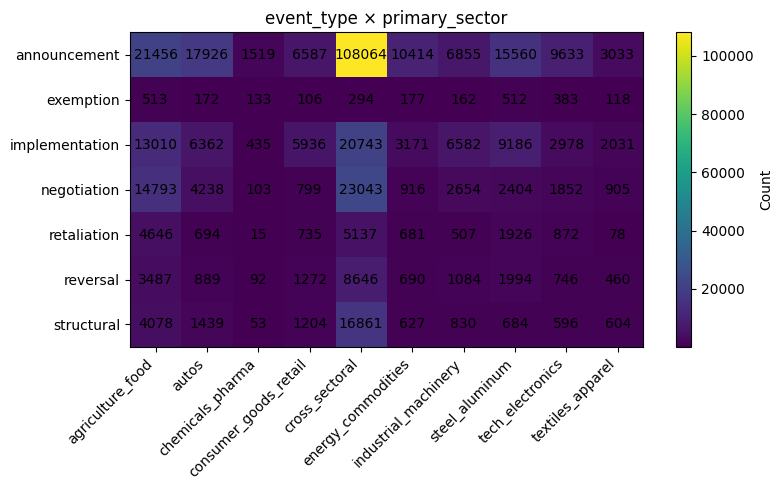

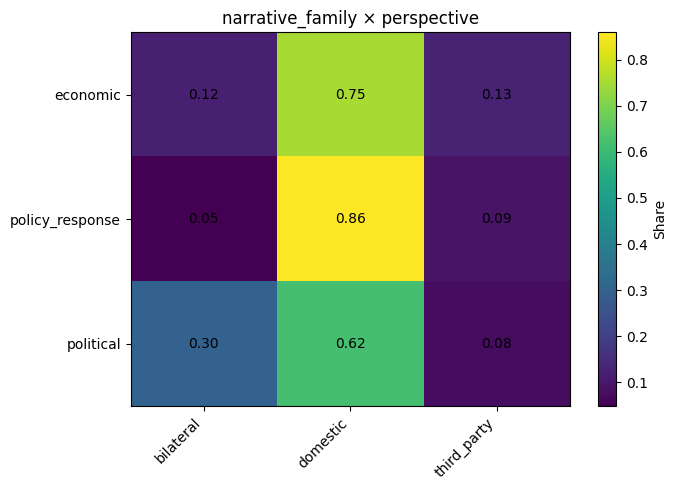

perspective,bilateral,domestic,third_party
narrative_family,,,
economic,0.120877,0.753493,0.125630
policy_response,0.048189,0.859364,0.092447
political,0.303705,0.620051,0.076245


In [ ]:
plot_crosstab_heatmap(analysis_df, "event_type", "primary_sector", normalize=False)
plot_crosstab_heatmap(analysis_df, "narrative_family", "perspective", normalize=True)


(336216, 61)


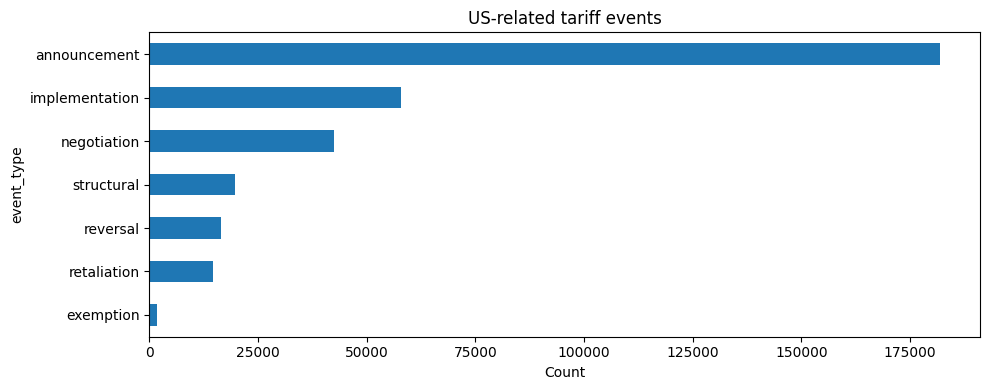

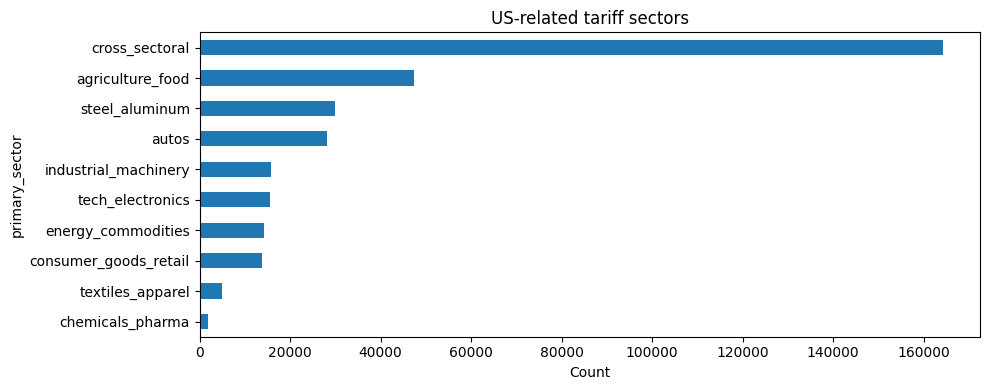

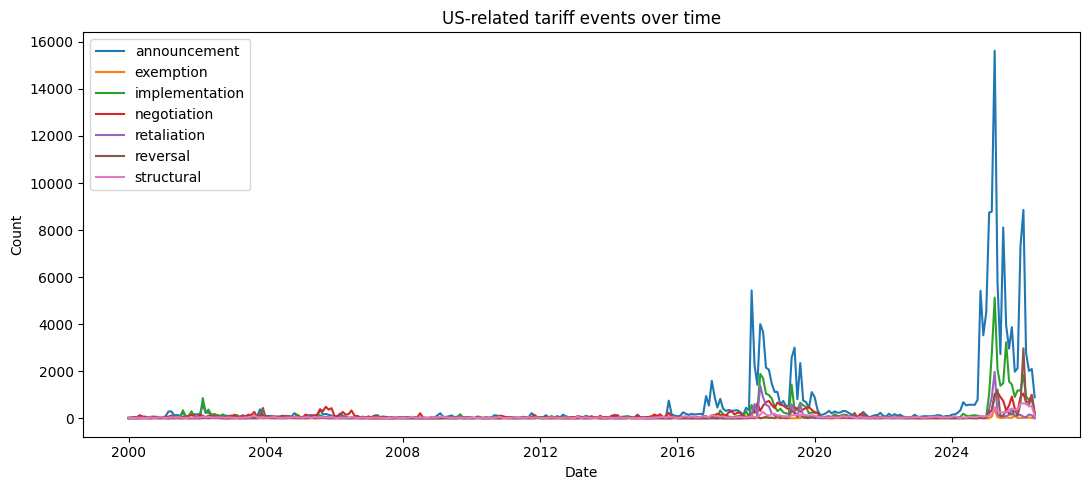

In [ ]:
# Example reusable filtered views
us_tariff_df = filter_data(
    df_clean,
    is_trade_tariff=True,
    mentioned_country="US",
    min_event_confidence=0.5,
)

print(us_tariff_df.shape)
plot_bar_counts(us_tariff_df, "event_type", title="US-related tariff events")
plot_bar_counts(us_tariff_df, "primary_sector", title="US-related tariff sectors")
plot_time_series(us_tariff_df, group_col="event_type", freq="M", title="US-related tariff events over time")


In [ ]:
# Save normalized outputs
df_to_save = df_clean.copy()

for col in ["sector_weights", "imposing_countries", "receiving_countries", "retaliating_countries", "mentioned_countries"]:
    df_to_save[col] = df_to_save[col].apply(lambda x: json.dumps(x, ensure_ascii=False) if isinstance(x, (dict, list)) else x)

df_to_save.to_parquet(CLEAN_PARQUET_PATH, index=False)
df_to_save.to_csv(CLEAN_CSV_PATH, index=False)

print("Saved:")
print(CLEAN_PARQUET_PATH)
print(CLEAN_CSV_PATH)
print(VALIDATION_REPORT_PATH)


Saved:
/content/drive/MyDrive/Survey Data/IMF/TARIFS_232/PROCESSED/wcb_tariff_normalized.parquet
/content/drive/MyDrive/Survey Data/IMF/TARIFS_232/PROCESSED/wcb_tariff_normalized.csv
/content/drive/MyDrive/Survey Data/IMF/TARIFS_232/PROCESSED/wcb_validation_report.csv
